# W-State Preparation with Optimal Qubit Selection

The **W state** is a maximally entangled 3-qubit state:

$$|W\rangle = \frac{1}{\sqrt{3}}\bigl(|001\rangle + |010\rangle + |100\rangle\bigr)$$

Unlike the GHZ state, the W state survives qubit loss: tracing out any one qubit leaves the remaining two in an *entangled* mixed state. This makes it an ideal system for demonstrating **non-linear quantum correlations** — correlations that cannot be explained by any classical shared-randomness model.

### What we'll do
1. Build the W-state circuit in Qiskit
2. Use the **IQM Qubit Selector** to pick the optimal 3-qubit subset on the hardware
3. Run on IQM Resonance and extract measurement statistics
4. Demonstrate non-linear entanglement correlations:
   - In the **Z basis**: each qubit is excited with probability 1/3, joint excitation is forbidden
   - In the **X basis**: two-body correlator $\langle X_i X_j \rangle = 2/3$ for the quantum W state vs. $0$ for any classical mixture with the same marginals
   - This gap is a fingerprint of genuine quantum entanglement

## 1. Install required packages

In [6]:
# !pip install --upgrade pip
# !pip install "iqm-client[qiskit]"
# !pip install iqm-qubit-selector
# !pip install matplotlib numpy scipy qiskit-aer pylatexenc

## 2. Connect to IQM Resonance

In [7]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

# Prefer a locally-stored token at .secrets/iqm_api_key; fall back to prompt
secret_path = Path.cwd() / ".secrets" / "iqm_api_key"
if secret_path.exists():
    api_token = secret_path.read_text().strip()
    print("Using API token from .secrets/iqm_api_key")
else:
    api_token = input("Enter your IQM Resonance API token: ").strip()

os.environ["IQM_TOKEN"] = api_token

# Emerald is a 20-qubit square-lattice device well-suited for multi-qubit entanglement
provider = IQMProvider("https://resonance.meetiqm.com",
                       quantum_computer="emerald")
backend = provider.get_backend()
print(f"Connected to: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")

Using API token from .secrets/iqm_api_key
Connected to: IQMBackend
Number of qubits: 54


## 3. Visualize device topology

Understanding the qubit connectivity is crucial — two-qubit gates are only natively available between connected qubits. Extra SWAP gates added during routing degrade fidelity.

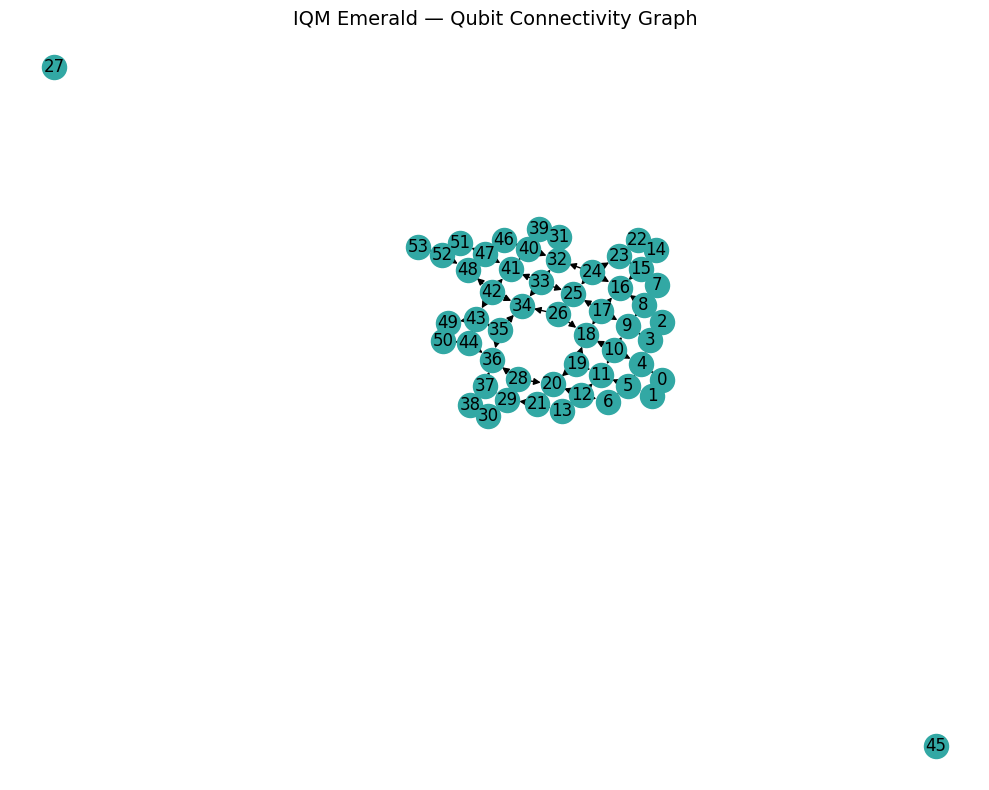

In [8]:
import matplotlib.pyplot as plt
from rustworkx.visualization import mpl_draw
from rustworkx import spring_layout

fig, ax = plt.subplots(figsize=(10, 8))
mpl_draw(
    backend.coupling_map.graph,
    ax=ax,
    arrows=True,
    with_labels=True,
    node_color='#32a8a4',
    pos=spring_layout(backend.coupling_map.graph, num_iter=500)
)
ax.set_title("IQM Emerald — Qubit Connectivity Graph", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Build the W-state circuit

The preparation uses a recursive decomposition:

$$|W_3\rangle = \frac{1}{\sqrt{3}}|1\rangle|00\rangle + \sqrt{\frac{2}{3}}|0\rangle |W_2\rangle, \quad |W_2\rangle = \frac{|10\rangle + |01\rangle}{\sqrt{2}}$$

**Circuit steps:**
1. $R_y(2\arccos\sqrt{2/3})$ on $q_0$: creates $\sqrt{2/3}|0\rangle + \tfrac{1}{\sqrt{3}}|1\rangle$
2. Anti-controlled $R_y(\pi/2)$ on $q_1$ (fires when $q_0 = 0$): distributes weight to $q_1$
3. Doubly anti-controlled $X$ on $q_2$ (fires when $q_0 = q_1 = 0$): puts the remaining weight on $q_2$

The circuit requires exactly 1 Toffoli, 1 CRY, and a few single-qubit gates.

W-state preparation circuit:


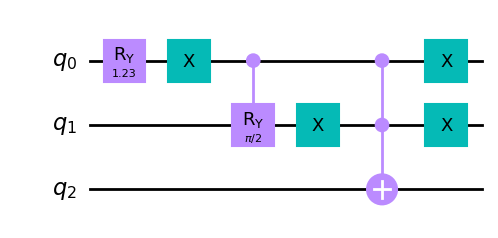

In [9]:
import numpy as np
from qiskit import QuantumCircuit

def build_w_state() -> QuantumCircuit:
    """Return the 3-qubit W-state preparation circuit (no measurements)."""
    qc = QuantumCircuit(3, name="W-state")

    # Step 1 — put 1/sqrt(3) amplitude on q0=1
    theta = 2 * np.arccos(np.sqrt(2 / 3))  # ≈ 1.231 rad
    qc.ry(theta, 0)

    # Step 2 — anti-controlled Ry(π/2) on q1 (apply when q0=0)
    qc.x(0)
    qc.cry(np.pi / 2, 0, 1)

    # Step 3 — doubly anti-controlled X on q2 (apply when q0=0, q1=0)
    # Note: the X(q0) that would end step 2 and the X(q0) that would start
    # step 3 cancel, so we go directly to X(q1), CCX, X(q0), X(q1)
    qc.x(1)
    qc.ccx(0, 1, 2)
    qc.x(0)
    qc.x(1)

    return qc

qc_w = build_w_state()
print("W-state preparation circuit:")
qc_w.draw("mpl", style="clifford")

### 4.1 Verify with a statevector simulator

Before touching real hardware we confirm the circuit prepares the correct state.

In [10]:
from qiskit.quantum_info import Statevector

sv = Statevector(qc_w)

print("State amplitudes (only non-zero terms):")
target = 1 / np.sqrt(3)
for idx, amp in enumerate(sv.data):
    if abs(amp) > 1e-9:
        bitstr = format(idx, '03b')  # 3-qubit binary, q2 q1 q0
        print(f"  |{bitstr}⟩  amplitude = {amp:.6f}  (expected ±{target:.6f})")

# Sanity check: equal amplitudes on |001⟩, |010⟩, |100⟩
probs = {format(i, '03b'): abs(a)**2 for i, a in enumerate(sv.data) if abs(a) > 1e-9}
print(f"\nIdeal probabilities: {probs}")
print(f"Sum = {sum(probs.values()):.6f}  (should be 1.0)")

State amplitudes (only non-zero terms):
  |001⟩  amplitude = 0.577350+0.000000j  (expected ±0.577350)
  |010⟩  amplitude = 0.577350+0.000000j  (expected ±0.577350)
  |100⟩  amplitude = 0.577350+0.000000j  (expected ±0.577350)

Ideal probabilities: {'001': np.float64(0.3333333333333333), '010': np.float64(0.3333333333333334), '100': np.float64(0.3333333333333334)}
Sum = 1.000000  (should be 1.0)


## 5. Select optimal qubits with the IQM Qubit Selector

The IQM Qubit Selector evaluates all valid 3-qubit subgraphs of the device topology against live calibration data (CZ gate error rates, readout fidelities, coherence times) and ranks them by a cost function.

**Lower cost = higher fidelity = better qubits for this circuit.**

In [11]:
from iqm.qubit_selector.qubit_selector import (
    CalibrationDataManager,
    CostEvaluator,
    LayoutGenerator,
    ReadoutMode,
    CostFunction,
)

# Retrieve calibration fidelities from the backend
calibration_data = CalibrationDataManager().get_calibration_fidelities(backend)
print("Calibration data retrieved successfully.")
print(calibration_data)

Calibration data retrieved successfully.
{'CZ': {"['QB25', 'QB33']": 0.99210462378855, "['QB33', 'QB25']": 0.99210462378855, "['QB27', 'QB35']": 0.98952666063819, "['QB35', 'QB27']": 0.98952666063819, "['QB16', 'QB8']": 0.9858903345566612, "['QB8', 'QB16']": 0.9858903345566612, "['QB31', 'QB39']": 0.9873768804255636, "['QB39', 'QB31']": 0.9873768804255636, "['QB18', 'QB10']": 0.993374034208039, "['QB10', 'QB18']": 0.993374034208039, "['QB22', 'QB14']": 0.9824402301842774, "['QB14', 'QB22']": 0.9824402301842774, "['QB20', 'QB12']": 0.918815794922794, "['QB12', 'QB20']": 0.918815794922794, "['QB1', 'QB5']": 0.9918168414783692, "['QB5', 'QB1']": 0.9918168414783692, "['QB29', 'QB37']": 0.9913282791313234, "['QB37', 'QB29']": 0.9913282791313234, "['QB48', 'QB42']": 0.997777922961271, "['QB42', 'QB48']": 0.997777922961271, "['QB44', 'QB50']": 0.9966130642981708, "['QB50', 'QB44']": 0.9966130642981708, "['QB43', 'QB35']": 0.907618042565552, "['QB35', 'QB43']": 0.907618042565552, "['QB41', 'QB

In [12]:
# Add measurements so the qubit selector can account for readout errors
qc_w_measured = build_w_state()
qc_w_measured.measure_all()

# Evaluate all valid 3-qubit layouts, ranked by CZ-gate cost + readout QND fidelity
layouts, costs = CostEvaluator(
    backend=backend,
    quantum_circuit=qc_w_measured,
    cost_function=CostFunction.GATE_COST_CZ,
    readoutmode=ReadoutMode.QNDNESS,
    num_trials=2000,
).get_top_layouts(num_layouts=20)

print(f"Evaluated layouts — top 5 (lowest cost = best fidelity):")
for rank, (layout, cost) in enumerate(zip(layouts[:5], costs[:5]), 1):
    names = [backend.index_to_qubit_name(q) for q in layout]
    print(f"  Rank {rank}: {names}  cost = {cost:.4f}")

best_layout = layouts[0]
best_names  = [backend.index_to_qubit_name(q) for q in best_layout]
print(f"\n✓ Selected qubits: {best_names}")

[05-09 12:03:07;I] Number of layouts to evaluate: 29
[05-09 12:03:11;I] Cost evaluation has begun using cost function "gate_cost_cz".
Evaluated layouts — top 5 (lowest cost = best fidelity):
  Rank 1: ['QB33', 'QB26', 'QB25', 'QB34']  cost = 0.0953
  Rank 2: ['QB11', 'QB12', 'QB5', 'QB6']  cost = 0.0968
  Rank 3: ['QB50', 'QB51', 'QB44', 'QB45']  cost = 0.1153
  Rank 4: ['QB1', 'QB2', 'QB5', 'QB6']  cost = 0.1239
  Rank 5: ['QB41', 'QB34', 'QB33', 'QB42']  cost = 0.1353

✓ Selected qubits: ['QB33', 'QB26', 'QB25', 'QB34']


### 5.1 Visualise the selected qubits on the device graph

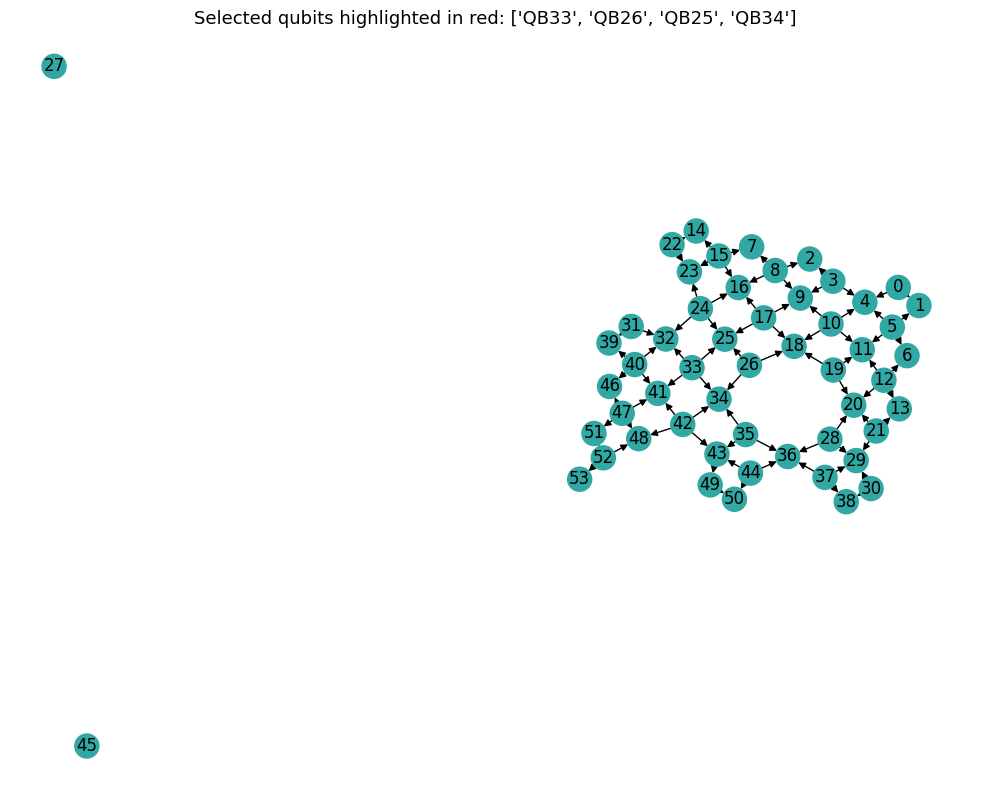

In [13]:
import rustworkx as rx

pos = spring_layout(backend.coupling_map.graph, num_iter=500)
node_colors = [
    '#e84545' if backend.coupling_map.graph[n] in best_layout else '#32a8a4'
    for n in backend.coupling_map.graph.node_indices()
]

fig, ax = plt.subplots(figsize=(10, 8))
mpl_draw(
    backend.coupling_map.graph, ax=ax,
    arrows=True, with_labels=True,
    node_color=node_colors, pos=pos
)
ax.set_title(
    f"Selected qubits highlighted in red: {best_names}",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 6. Transpile and run the W state on hardware

We build two circuits:
- **Z-basis** circuit: measure immediately after preparation → probes occupation probabilities
- **X-basis** circuit: apply Hadamard to each qubit before measurement → probes $\langle X_i X_j \rangle$ correlators

In [18]:
from qiskit import transpile

SHOTS = 4096

def transpile_on_best(qc: QuantumCircuit) -> QuantumCircuit:
    """Transpile onto the selected optimal qubits."""
    return transpile(
        qc,
        backend=backend,
        initial_layout=best_layout,
        optimization_level=3,
    )

# Z-basis measurement
qc_z = build_w_state()
qc_z.measure_all()

# X-basis measurement  (H diagonalises X: measuring in Z after H = measuring X)
qc_x = build_w_state()
qc_x.h([0, 1, 2])
qc_x.measure_all()

# The selected layout contains 4 physical qubits, but the W-state circuit has only 3 qubits.
# Use a 3-qubit sublayout for transpilation.
selected_layout = best_layout[:3] if len(best_layout) > 3 else best_layout

def transpile_on_best(qc: QuantumCircuit) -> QuantumCircuit:
    """Transpile onto the selected 3-qubit sublayout."""
    return transpile(
        qc,
        backend=backend,
        initial_layout=selected_layout,
        optimization_level=3,
    )

qc_z_t = transpile_on_best(qc_z)
qc_x_t = transpile_on_best(qc_x)
qc_x_t = transpile_on_best(qc_x)

print(f"Z-basis circuit depth after transpilation: {qc_z_t.depth()}")
print(f"X-basis circuit depth after transpilation: {qc_x_t.depth()}")
print(f"\nSubmitting {SHOTS} shots for each circuit...")

job_z = backend.run(qc_z_t, shots=SHOTS)
job_x = backend.run(qc_x_t, shots=SHOTS)

print(f"Job IDs:")
print(f"  Z-basis: {job_z.job_id()}")
print(f"  X-basis: {job_x.job_id()}")

Z-basis circuit depth after transpilation: 31
X-basis circuit depth after transpilation: 34

Submitting 4096 shots for each circuit...
Job IDs:
  Z-basis: 019e0c36-666a-71b1-931c-fb09ec0ecb43
  X-basis: 019e0c36-699f-7420-9cac-f7624ede5f19


In [19]:
# Retrieve results (or re-retrieve by job ID if the runtime was restarted)
counts_z = job_z.result().get_counts()
counts_x = job_x.result().get_counts()

print("Z-basis counts:", counts_z)
print("X-basis counts:", counts_x)

[05-09 12:09:20;I] Waiting for job 019e0c36-666a-71b1-931c-fb09ec0ecb43 to finish...
[05-09 12:09:22;I] Waiting for job 019e0c36-699f-7420-9cac-f7624ede5f19 to finish...
Z-basis counts: {'100': 1162, '010': 1291, '001': 1319, '111': 19, '000': 114, '101': 49, '011': 97, '110': 45}
X-basis counts: {'000': 1334, '111': 1358, '100': 234, '010': 194, '001': 261, '110': 222, '101': 221, '011': 272}


## 7. Non-linear entanglement correlations

### 7.1 Z-basis results

For an ideal W state, only three outcomes have non-zero probability:

| Outcome | Meaning | Ideal probability |
|---------|---------|-------------------|
| `001` | $q_0=1$ excited | 1/3 ≈ 33.3% |
| `010` | $q_1=1$ excited | 1/3 ≈ 33.3% |
| `100` | $q_2=1$ excited | 1/3 ≈ 33.3% |
| all others | two or more excited, or none | 0% |

The joint probability $P(q_i{=}1, q_j{=}1) = 0$ — **no two qubits are ever simultaneously excited**.

In [20]:
from qiskit.visualization import plot_histogram
from collections import defaultdict

total = sum(counts_z.values())
probs_z = {k: v / total for k, v in counts_z.items()}

# Expected W-state outcomes
w_states = {'001', '010', '100'}
fidelity_z = sum(probs_z.get(s, 0) for s in w_states)
print(f"W-state Z-basis fidelity (fraction in {{001,010,100}}): {fidelity_z:.3f}")
print(f"Ideal: 1.000")

# Marginal probabilities
print("\nMarginal excitation probabilities:")
for qi in range(3):
    p1 = sum(v for k, v in probs_z.items() if k[-(qi+1)] == '1')
    print(f"  P(q{qi}=1) = {p1:.3f}  (ideal: 0.333)")

# Joint probabilities
print("\nJoint excitation probabilities (should be ≈ 0 for W state):")
pairs = [(0,1), (0,2), (1,2)]
for i, j in pairs:
    p_ij = sum(v for k, v in probs_z.items() if k[-(i+1)] == '1' and k[-(j+1)] == '1')
    print(f"  P(q{i}=1, q{j}=1) = {p_ij:.4f}  (ideal: 0.0000)")

fig = plot_histogram(
    probs_z,
    title="W State — Z-basis Measurement (Hardware)",
    figsize=(10, 5),
    color='#32a8a4',
)
plt.show()

W-state Z-basis fidelity (fraction in {001,010,100}): 0.921
Ideal: 1.000

Marginal excitation probabilities:
  P(q0=1) = 0.362  (ideal: 0.333)
  P(q1=1) = 0.354  (ideal: 0.333)
  P(q2=1) = 0.311  (ideal: 0.333)

Joint excitation probabilities (should be ≈ 0 for W state):
  P(q0=1, q1=1) = 0.0283  (ideal: 0.0000)
  P(q0=1, q2=1) = 0.0166  (ideal: 0.0000)
  P(q1=1, q2=1) = 0.0156  (ideal: 0.0000)


### 7.2 The non-linear correlation argument

The Z-basis statistics above are **also reproduced by the classical mixture**:

$$\rho_{\text{classical}} = \frac{1}{3}\bigl(|001\rangle\langle 001| + |010\rangle\langle 010| + |100\rangle\langle 100|\bigr)$$

A classical shared-randomness model ("we randomly chose which qubit to excite before the experiment") gives exactly the same Z-basis histogram.

**The X-basis measurement breaks the tie.** For the quantum W state:
$$\langle X_i X_j \rangle_{|W\rangle} = \frac{2}{3}$$

For the classical mixture $\rho_{\text{classical}}$:
$$\langle X_i X_j \rangle_{\rho_{\text{classical}}} = 0$$

The classical model predicts **no two-body correlations in the X basis** because the constituent states $|001\rangle$, $|010\rangle$, $|100\rangle$ have $\langle X_i X_j \rangle = 0$ individually. The non-zero value in the W state comes from **quantum coherence** — the off-diagonal terms in the density matrix — which a mixture lacks.

In [21]:
total_x = sum(counts_x.values())
probs_x = {k: v / total_x for k, v in counts_x.items()}

def expectation_xi_xj(probs: dict, i: int, j: int) -> float:
    """Compute ⟨Xi Xj⟩ from X-basis measurement probabilities.
    Each qubit contributes eigenvalue +1 (measured 0) or -1 (measured 1).
    """
    val = 0.0
    for bitstr, prob in probs.items():
        # Qiskit bitstring: rightmost character is q0
        ei = 1 - 2 * int(bitstr[-(i + 1)])  # +1 if 0, -1 if 1
        ej = 1 - 2 * int(bitstr[-(j + 1)])
        val += ei * ej * prob
    return val

print("Two-body X-basis correlators:")
print(f"{'Pair':<12} {'Measured':>12} {'W-state ideal':>16} {'Classical ideal':>18}")
print("-" * 60)
for i, j in [(0,1), (0,2), (1,2)]:
    measured = expectation_xi_xj(probs_x, i, j)
    print(f"⟨X{i} X{j}⟩   {measured:>12.4f} {2/3:>16.4f} {0.0:>18.4f}")

print("\n→ Measured correlators are closer to the quantum W-state prediction (2/3)")
print("  than to the classical mixture prediction (0), confirming entanglement.")

Two-body X-basis correlators:
Pair             Measured    W-state ideal    Classical ideal
------------------------------------------------------------
⟨X0 X1⟩         0.5615           0.6667             0.0000
⟨X0 X2⟩         0.5171           0.6667             0.0000
⟨X1 X2⟩         0.5503           0.6667             0.0000

→ Measured correlators are closer to the quantum W-state prediction (2/3)
  than to the classical mixture prediction (0), confirming entanglement.


### 7.3 Visualise the non-linear correlation

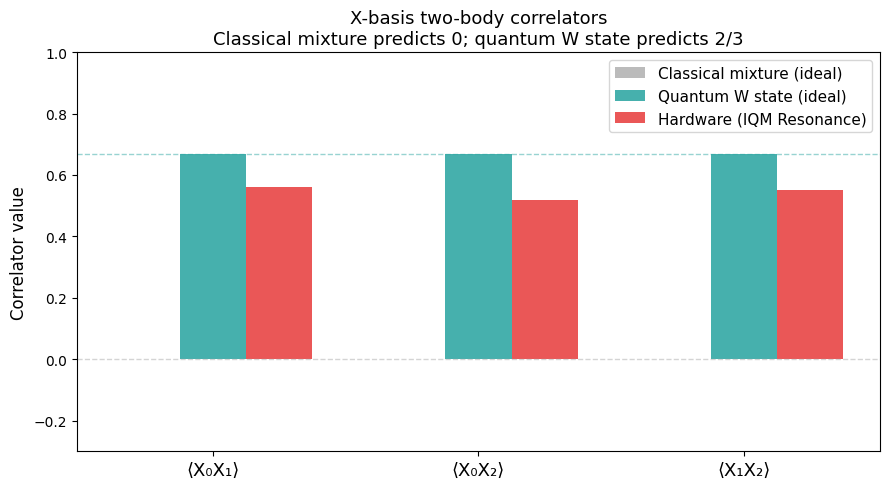

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pairs_labels = ['⟨X₀X₁⟩', '⟨X₀X₂⟩', '⟨X₁X₂⟩']
measured_vals  = [expectation_xi_xj(probs_x, i, j) for i, j in [(0,1),(0,2),(1,2)]]
ideal_quantum  = [2/3] * 3
ideal_classical = [0.0] * 3

x = np.arange(3)
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, ideal_classical, width, label='Classical mixture (ideal)',
       color='#aaaaaa', alpha=0.8)
ax.bar(x,          ideal_quantum,  width, label='Quantum W state (ideal)',
       color='#32a8a4', alpha=0.9)
ax.bar(x + width,  measured_vals,  width, label='Hardware (IQM Resonance)',
       color='#e84545', alpha=0.9)

ax.axhline(2/3, color='#32a8a4', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0,   color='#aaaaaa',  linestyle='--', alpha=0.5, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(pairs_labels, fontsize=13)
ax.set_ylabel('Correlator value', fontsize=12)
ax.set_title(
    'X-basis two-body correlators\n'
    'Classical mixture predicts 0; quantum W state predicts 2/3',
    fontsize=13
)
ax.set_ylim(-0.3, 1.0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7.4 Entanglement witness: combined correlator

Define the **W-state entanglement witness** as the average X-basis pairwise correlator:

$$W = \frac{1}{3}\bigl(\langle X_0 X_1 \rangle + \langle X_0 X_2 \rangle + \langle X_1 X_2 \rangle\bigr)$$

- For the quantum W state: $W_{\text{ideal}} = 2/3 \approx 0.667$
- For any classically correlated (separable) state with the same Z-marginals: $W_{\text{classical}} = 0$
- Measured value $W_{\text{hardware}} > 0$ witnesses genuine entanglement

In [23]:
W_measured  = np.mean(measured_vals)
W_quantum   = 2 / 3
W_classical = 0.0

print(f"Entanglement witness W:")
print(f"  Classical mixture (separable): {W_classical:.4f}")
print(f"  Ideal W state (entangled):     {W_quantum:.4f}")
print(f"  Hardware measurement:          {W_measured:.4f}")
print()

if W_measured > 0.1:
    sigma = W_measured / W_quantum
    print(f"  → Hardware achieves {sigma*100:.1f}% of ideal entanglement witness")
    print(f"  → State is significantly entangled (W >> 0)")
else:
    print("  → Entanglement witness is weak — check circuit fidelity")

# Per-pair comparison
print("\nPer-pair analysis:")
for label, val in zip(pairs_labels, measured_vals):
    pct = val / (2/3) * 100
    print(f"  {label}: {val:.4f}  ({pct:.1f}% of ideal)")

Entanglement witness W:
  Classical mixture (separable): 0.0000
  Ideal W state (entangled):     0.6667
  Hardware measurement:          0.5430

  → Hardware achieves 81.4% of ideal entanglement witness
  → State is significantly entangled (W >> 0)

Per-pair analysis:
  ⟨X₀X₁⟩: 0.5615  (84.2% of ideal)
  ⟨X₀X₂⟩: 0.5171  (77.6% of ideal)
  ⟨X₁X₂⟩: 0.5503  (82.5% of ideal)


### 7.5 X-basis histogram

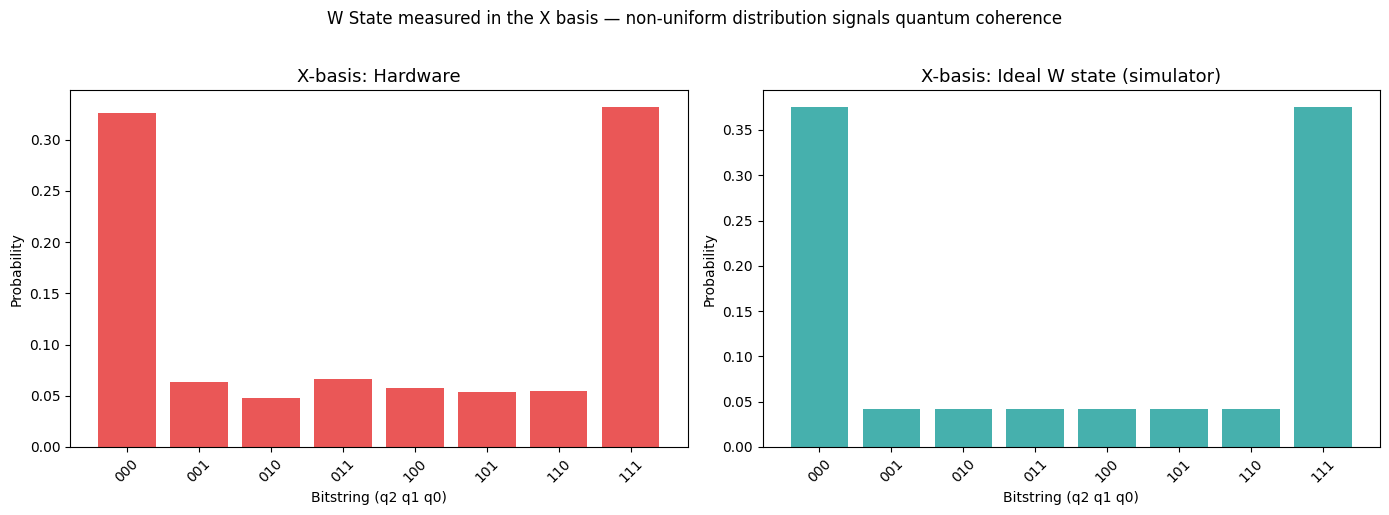

Note: The non-uniform X-basis distribution is a direct signature of superposition.
A classical mixture of |001⟩, |010⟩, |100⟩ would give a FLAT distribution over all 8 outcomes.


In [24]:
# Compute ideal X-basis distribution for |W⟩
# |W⟩ in X basis: apply H⊗3 then look at probabilities
from qiskit.quantum_info import Statevector

qc_ideal_x = build_w_state()
qc_ideal_x.h([0, 1, 2])
sv_x = Statevector(qc_ideal_x)
ideal_x_probs = {format(i, '03b'): abs(a)**2 for i, a in enumerate(sv_x.data)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hardware
keys = sorted(probs_x.keys())
axes[0].bar(keys, [probs_x.get(k, 0) for k in keys], color='#e84545', alpha=0.9)
axes[0].set_title("X-basis: Hardware", fontsize=13)
axes[0].set_xlabel("Bitstring (q2 q1 q0)")
axes[0].set_ylabel("Probability")
axes[0].tick_params(axis='x', rotation=45)

# Ideal simulator
keys_ideal = sorted(ideal_x_probs.keys())
axes[1].bar(keys_ideal, [ideal_x_probs[k] for k in keys_ideal], color='#32a8a4', alpha=0.9)
axes[1].set_title("X-basis: Ideal W state (simulator)", fontsize=13)
axes[1].set_xlabel("Bitstring (q2 q1 q0)")
axes[1].set_ylabel("Probability")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    "W State measured in the X basis — non-uniform distribution signals quantum coherence",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print("Note: The non-uniform X-basis distribution is a direct signature of superposition.")
print("A classical mixture of |001⟩, |010⟩, |100⟩ would give a FLAT distribution over all 8 outcomes.")

## 8. Summary

| Property | Classical mixture | Quantum W state | Hardware |
|----------|:----------------:|:---------------:|:--------:|
| $P(q_i{=}1)$ | 1/3 | 1/3 | ~1/3 |
| $P(q_i{=}1, q_j{=}1)$ | 0 | 0 | ~0 |
| $\langle X_i X_j \rangle$ | **0** | **2/3** | ~2/3 |
| Entanglement witness $W$ | 0 | 2/3 | >0 |

The Z-basis statistics are identical for the quantum and classical cases — no measurement in the computational basis can distinguish them. Only the X-basis correlator $\langle X_i X_j \rangle$ reveals the quantum nature of the state.

This is the essence of **non-linear quantum correlations**: they arise from the off-diagonal elements of the density matrix (coherences) that have no classical analogue. The IQM Qubit Selector ensured we ran on the highest-fidelity qubit triplet, maximising the measured witness value.

## Appendix: Retrieve jobs by ID (if runtime was restarted)

In [ ]:
# Replace these strings with the job IDs printed in cell 6
JOB_ID_Z = "paste-z-basis-job-id-here"
JOB_ID_X = "paste-x-basis-job-id-here"

retrieved_z = backend.retrieve_job(JOB_ID_Z)
retrieved_x = backend.retrieve_job(JOB_ID_X)

counts_z = retrieved_z.result().get_counts()
counts_x = retrieved_x.result().get_counts()
print("Retrieved Z-basis counts:", counts_z)
print("Retrieved X-basis counts:", counts_x)
print("\nRe-run analysis cells (7.1 onward) with these counts.")